In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

In [3]:
from langchain.chat_models import init_chat_model


In [4]:
gemini_llm = init_chat_model(model="gemini-2.0-flash-lite-001", model_provider="google_vertexai")


In [5]:
# Tools are where we have our functionality and we want llm to call our tool
from langchain.tools import tool

@tool("addition", parse_docstring=True, return_direct=True)
def add(a: int, b: int) -> int:
    """Addition of two numbers

    Args:
      a : number
      b : number

    Returns: sum of a, b
    """
    return a + b

In [6]:
@tool("subtraction", parse_docstring=True, return_direct=True)
def sub(a: int, b: int) -> int:
    """Subtract two numbers

    Args:
      a : number
      b : number

    """
    return a - b

In [7]:
@tool("multipy", parse_docstring=True, return_direct=True)
def mul(a: int, b: int) -> int:
    """Multiplication of two numbers

    Args:
      a : number
      b : number

    """
    return a * b

In [8]:
@tool("divide", parse_docstring=True, return_direct=True)
def div(a: int, b: int) -> int:
    """division of two numbers

    Args:
      a : number
      b : number

    """
    return a // b

In [9]:
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage

In [10]:
from IPython.display import Image, display
def display_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
tool_node = ToolNode([add, sub, mul,div])
prompt = SystemMessage("You are an helpful assistantf")
agent = create_react_agent(
    model=gemini_llm,
    tools=tool_node,
    prompt=prompt)

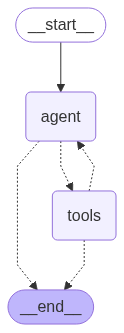

In [12]:
display_graph(agent)


In [13]:
response = agent.invoke({"messages": "What is 4 * 5 ?"})


In [14]:
response

{'messages': [HumanMessage(content='What is 4 * 5 ?', additional_kwargs={}, response_metadata={}, id='f64bb7f2-8fa0-4d70-9184-fc96ed91cce7'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multipy', 'arguments': '{"b": 5.0, "a": 4.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 71, 'candidates_token_count': 6, 'total_token_count': 77, 'prompt_tokens_details': [{'modality': 1, 'token_count': 71}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 6}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.001376562596609195, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--ad40892b-e8e5-4968-a9cc-6f11b4f180bb-0', tool_calls=[{'name': 'multipy', 'args': {'b': 5.0, 'a': 4.0}, 'id': '0013cd22-2080-4961-8563-e34e8aa23c6b', 'type': 'tool_call'}], usage_metadata={'input_tokens': 71, 'output_tokens': 6, 'total_tokens':

In [20]:
user_input = input("Enter your question ?")
for step in agent.stream(
    {"messages": user_input},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

what is 10 divide by 2
================================== Ai Message ==================================
Tool Calls:
  divide (98b74e31-2a9d-41d0-a02e-c9b80db719de)
 Call ID: 98b74e31-2a9d-41d0-a02e-c9b80db719de
  Args:
    b: 2.0
    a: 10.0
================================= Tool Message =================================
Name: divide

5
